#### Подключение библиотек и загрузка датасета

In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
diabetes_df = pd.read_csv('diabetes_clean.csv')
print(diabetes_df.head(10))
print(diabetes_df.shape)
print(diabetes_df.columns)

   pregnancies  glucose  diastolic  triceps  ...   bmi    dpf  age  diabetes
0            6      148         72       35  ...  33.6  0.627   50         1
1            1       85         66       29  ...  26.6  0.351   31         0
2            8      183         64        0  ...  23.3  0.672   32         1
3            1       89         66       23  ...  28.1  0.167   21         0
4            0      137         40       35  ...  43.1  2.288   33         1
5            5      116         74        0  ...  25.6  0.201   30         0
6            3       78         50       32  ...  31.0  0.248   26         1
7           10      115          0        0  ...  35.3  0.134   29         0
8            2      197         70       45  ...  30.5  0.158   53         1
9            8      125         96        0  ...   0.0  0.232   54         1

[10 rows x 9 columns]
(768, 9)
Index(['pregnancies', 'glucose', 'diastolic', 'triceps', 'insulin', 'bmi',
       'dpf', 'age', 'diabetes'],
      dtype=

In [155]:
print(diabetes_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   pregnancies  768 non-null    int64  
 1   glucose      768 non-null    int64  
 2   diastolic    768 non-null    int64  
 3   triceps      768 non-null    int64  
 4   insulin      768 non-null    int64  
 5   bmi          768 non-null    float64
 6   dpf          768 non-null    float64
 7   age          768 non-null    int64  
 8   diabetes     768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


#### Исключение аномальных значений

In [156]:
diabetes_df = diabetes_df[diabetes_df['bmi'] > 0]
diabetes_df = diabetes_df[diabetes_df['glucose'] > 0]
diabetes_df = diabetes_df[diabetes_df['diastolic'] > 0]
diabetes_df = diabetes_df[diabetes_df['triceps'] > 0]
diabetes_df = diabetes_df[diabetes_df['insulin'] > 0]
diabetes_df = diabetes_df[diabetes_df['dpf'] > 0]

In [157]:
print(diabetes_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 3 to 765
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   pregnancies  392 non-null    int64  
 1   glucose      392 non-null    int64  
 2   diastolic    392 non-null    int64  
 3   triceps      392 non-null    int64  
 4   insulin      392 non-null    int64  
 5   bmi          392 non-null    float64
 6   dpf          392 non-null    float64
 7   age          392 non-null    int64  
 8   diabetes     392 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 30.6 KB
None


#### Разбивка данных на целевую переменную и массив признаков

In [158]:
X = diabetes_df.drop('glucose', axis=1).values
y = diabetes_df['glucose']

In [159]:
print(X)
print(y)

[[ 1.    66.    23.    ...  0.167 21.     0.   ]
 [ 0.    40.    35.    ...  2.288 33.     1.   ]
 [ 3.    50.    32.    ...  0.248 26.     1.   ]
 ...
 [ 2.    58.    26.    ...  0.766 22.     0.   ]
 [10.    76.    48.    ...  0.171 63.     0.   ]
 [ 5.    72.    23.    ...  0.245 30.     0.   ]]
3       89
4      137
6       78
8      197
13     189
      ... 
753    181
755    128
760     88
763    101
765    121
Name: glucose, Length: 392, dtype: int64


#### Предсказание по одной переменной

In [160]:
X_bmi = X[ :, 4]

In [161]:
print(X_bmi)

[28.1 43.1 31.  30.5 30.1 25.8 45.8 43.3 34.6 39.3 36.6 31.1 23.2 22.2
 31.6 24.8 24.  37.1 34.  45.4 19.4 24.2 24.4 33.7 34.7 37.7 46.8 41.5
 25.4 19.6 28.9 32.9 28.6 35.1 29.3 32.4 38.5 37.1 32.  46.7 24.7 33.9
 20.4 28.7 49.7 26.6 28.7 29.5 34.3 37.4 33.3 34.  31.2 30.5 23.2 53.2
 33.6 55.  42.9 33.3 34.5 29.7 34.5 21.1 33.8 30.8 28.7 36.9 32.5 32.8
 30.5 37.4 34.3 40.6 24.6 25.2 29.  40.9 37.2 44.2 29.9 28.4 35.4 43.5
 29.7 32.7 67.1 34.9 30.1 32.  27.9 31.6 33.1 39.4 22.9 34.8 30.9 20.4
 37.7 37.5 33.2 42.6 34.2 41.8 35.8 30.  34.6 28.8 23.6 34.6 36.7 45.2
 46.2 25.4 29.7 35.9 33.1 27.1 38.2 52.3 35.4 24.4 27.6 25.9 33.3 30.9
 33.6 25.2 33.2 40.5 27.8 25.3 35.9 32.4 26.  38.7 45.6 20.8 36.1 36.9
 36.6 43.3 40.5 35.5 28.  30.7 36.6 31.6 35.8 39.7 25.5 24.8 30.5 32.9
 39.4 26.6 29.5 34.1 19.3 38.1 27.5 26.8 25.6 35.1 45.5 30.8 32.7 23.9
 47.9 34.2 25.9 25.9 38.5 28.7 21.8 27.2 33.3 35.3 36.5 31.2 34.9 34.
 27.5 32.8 38.4 35.8 34.9 36.2 39.2 25.2 37.2 43.4 30.8 25.4 25.1 24.3
 22.3 3

In [162]:
print(X_bmi.shape)
print(y.shape)

(392,)
(392,)


In [163]:
X_bmi = X_bmi.reshape(-1, 1)
print(X_bmi.shape)
print(X_bmi)

(392, 1)
[[28.1]
 [43.1]
 [31. ]
 [30.5]
 [30.1]
 [25.8]
 [45.8]
 [43.3]
 [34.6]
 [39.3]
 [36.6]
 [31.1]
 [23.2]
 [22.2]
 [31.6]
 [24.8]
 [24. ]
 [37.1]
 [34. ]
 [45.4]
 [19.4]
 [24.2]
 [24.4]
 [33.7]
 [34.7]
 [37.7]
 [46.8]
 [41.5]
 [25.4]
 [19.6]
 [28.9]
 [32.9]
 [28.6]
 [35.1]
 [29.3]
 [32.4]
 [38.5]
 [37.1]
 [32. ]
 [46.7]
 [24.7]
 [33.9]
 [20.4]
 [28.7]
 [49.7]
 [26.6]
 [28.7]
 [29.5]
 [34.3]
 [37.4]
 [33.3]
 [34. ]
 [31.2]
 [30.5]
 [23.2]
 [53.2]
 [33.6]
 [55. ]
 [42.9]
 [33.3]
 [34.5]
 [29.7]
 [34.5]
 [21.1]
 [33.8]
 [30.8]
 [28.7]
 [36.9]
 [32.5]
 [32.8]
 [30.5]
 [37.4]
 [34.3]
 [40.6]
 [24.6]
 [25.2]
 [29. ]
 [40.9]
 [37.2]
 [44.2]
 [29.9]
 [28.4]
 [35.4]
 [43.5]
 [29.7]
 [32.7]
 [67.1]
 [34.9]
 [30.1]
 [32. ]
 [27.9]
 [31.6]
 [33.1]
 [39.4]
 [22.9]
 [34.8]
 [30.9]
 [20.4]
 [37.7]
 [37.5]
 [33.2]
 [42.6]
 [34.2]
 [41.8]
 [35.8]
 [30. ]
 [34.6]
 [28.8]
 [23.6]
 [34.6]
 [36.7]
 [45.2]
 [46.2]
 [25.4]
 [29.7]
 [35.9]
 [33.1]
 [27.1]
 [38.2]
 [52.3]
 [35.4]
 [24.4]
 [27.6]
 [25.9]

#### Просмотр данных (глюкоза/BMI)

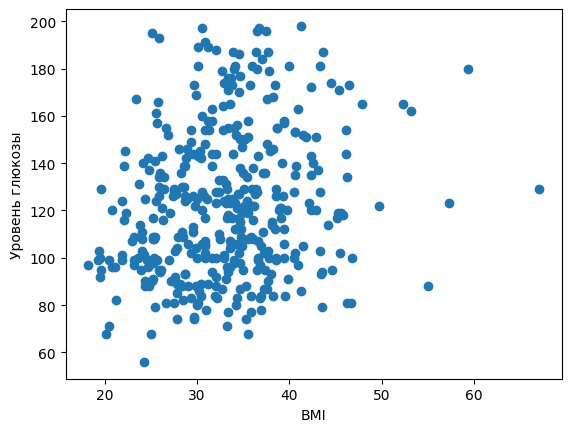

In [164]:
plt.scatter(X_bmi, y)
plt.ylabel('Уровень глюкозы')
plt.xlabel('BMI')
plt.show()

#### Создание модели

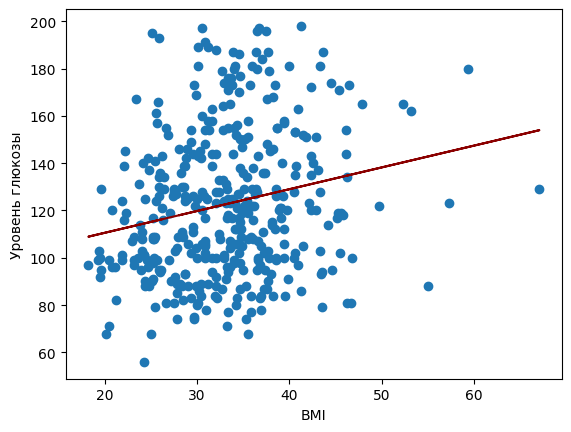

In [165]:
reg = LinearRegression()
reg.fit(X_bmi, y)
predictions = reg.predict(X_bmi)
plt.scatter(X_bmi, y)
plt.plot(X_bmi, predictions, color = 'darkred')
plt.ylabel('Уровень глюкозы')
plt.xlabel('BMI')
plt.show()

In [166]:
reg.score(X_bmi, y)

0.04389692023833025

#### Линейная регрессия для множества признаков

In [167]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
reg_all = LinearRegression()
reg_all.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [168]:
X_train.shape

(313, 8)

In [169]:
reg_all.coef_

array([-4.58308886e-01,  1.25213192e-01,  1.67771319e-02,  1.08114705e-01,
       -3.38078216e-02, -1.24765440e+00,  3.53630747e-01,  2.27656959e+01])

In [170]:
reg_all.intercept_

81.24392533150849

#### Оценка R-квадрат

In [171]:
print(reg_all.score(X_train, y_train))
print(reg_all.score(X_test, y_test))

0.45776518343694783
0.566696900135536


#### Кросвалидация

In [172]:
from sklearn.model_selection import cross_val_score, KFold
kf = KFold(n_splits=12, shuffle=True, random_state=42)
reg = LinearRegression()
cv_results = cross_val_score(reg, X, y, cv = kf)

In [173]:
print(cv_results)

[0.59471227 0.49919026 0.45133364 0.45710556 0.3220995  0.17991901
 0.41302036 0.52064279 0.48913975 0.50980929 0.46960942 0.46664601]


In [174]:
print(np.mean(cv_results))

0.4477689872661517


#### Гребневая регрессия

In [ ]:
from sklearn.linear_model import Ridge
scores = []
for alpha in [0, 0.001, 0.01, 0.1, 1, 10, 100, 1000]: # 10
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    scores.append(ridge.score(X_test, y_test))
print(scores)

[0.5666969001355364, 0.5666979737387605, 0.5667076301891295, 0.5668036049211143, 0.567706422127936, 0.572591565630874, 0.5546920379064662, 0.518393405005131]


#### Лассо регрессия

In [ ]:
from sklearn.linear_model import Lasso
scores = []
for alpha in [0.001, 0.01, 0.1, 1, 10, 100, 1000]: # 1
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train, y_train)
    scores.append(lasso.score(X_test, y_test))
print(scores)

[0.5667295477390153, 0.5670213042003975, 0.5697454822740409, 0.5746032000511734, 0.49916712212094505, 0.40441109730228997, 0.2850265694337525]


#### Выбор признаков с помощью Лассо регрессии

In [209]:
lasso = Lasso(alpha=1)
lasso.fit(X_train, y_train)
lasso_coef = lasso.coef_

In [210]:
print(lasso_coef)

[-0.12062254  0.13917771  0.03600375  0.11476428  0.          0.
  0.33885957 16.66884703]


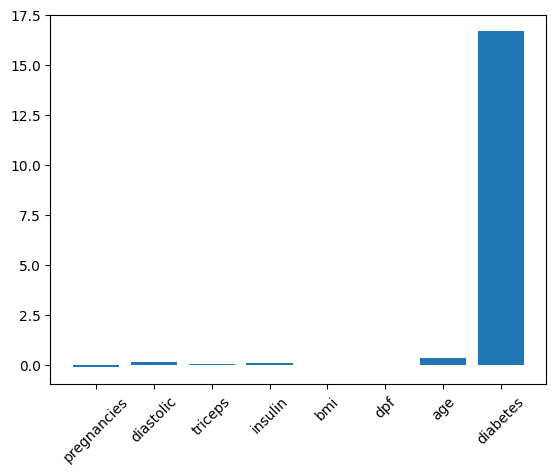

In [212]:
names = diabetes_df.drop('glucose', axis=1).columns
plt.bar(names, lasso_coef)
plt.xticks(rotation = 45)
plt.show()

#### Кроссвалидация (Ridge)

In [218]:
from sklearn.model_selection import cross_val_score, KFold
kf = KFold(n_splits=12, shuffle=True, random_state=42)
max_cv_reults = 0
best_alpha = -1
for alpha in [0, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]:
    reg = Ridge(alpha=alpha)
    cv_results = cross_val_score(reg, X, y, cv = kf)
    if max_cv_reults < np.mean(cv_results):
        max_cv_reults = np.mean(cv_results)
        best_alpha = alpha
print(max_cv_reults, alpha)

0.4479900323855444 10000


#### Кроссвалидация (Lasso)

In [221]:
from sklearn.model_selection import cross_val_score, KFold
kf = KFold(n_splits=12, shuffle=True, random_state=42)
max_cv_reults = 0
best_alpha = -1
for alpha in [0.001, 0.01, 0.1, 1, 10]:
    reg = Lasso(alpha=alpha)
    cv_results = cross_val_score(reg, X, y, cv = kf)
    if max_cv_reults < np.mean(cv_results):
        max_cv_reults = np.mean(cv_results)
        best_alpha = alpha
print(max_cv_reults, alpha)

0.4499358220865668 10
